# Data Visualization - Assignment 4
**Student ID:** 2023303

---

## GitHub Pages Link
**Live Dashboard:** https://mariumgk.github.io/DataVis-Assignment4/

---

## Datasets Overview

| # | Dataset | Visualization Type | Layouts Used |
|---|---|---|---|
| 1 | HRDataset_v14.csv | Tree | Treemap, Dendrogram |
| 2 | routes.csv (OpenFlights) | Graph | Spring (Force-Directed), Circular (Shell) |

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import plotly.io as pio
import scipy.cluster.hierarchy as sch
import os

# Colour palette (dark monochromatic)
BG='#0B0F1A'; SURFACE='#111827'; PRIMARY='#1E3A8A'
SECONDARY='#0EA5A4'; ACCENT='#22D3EE'; TEXT_PRI='#E5E7EB'; TEXT_SEC='#9CA3AF'

matplotlib.rcParams.update({
    'figure.facecolor':BG, 'axes.facecolor':SURFACE, 'axes.edgecolor':TEXT_SEC,
    'axes.labelcolor':TEXT_PRI, 'xtick.color':TEXT_SEC, 'ytick.color':TEXT_SEC,
    'text.color':TEXT_PRI, 'grid.color':'#1F2937', 'font.family':'DejaVu Sans',
    'font.size':11, 'legend.facecolor':SURFACE, 'legend.edgecolor':TEXT_SEC,
})
pio.templates.default = 'plotly_dark'
os.makedirs('visualizations', exist_ok=True)
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Dataset 1: HR Dataset (Tree Visualization)

**Source:** IBM HR Analytics - HRDataset_v14.csv  
**File:** `HRDataset_v14.csv` (311 employees, 36 columns)

This dataset records employee information for a mid-size manufacturing company.
It is ideal for **tree visualization** because the data has a natural strict hierarchy.

### Hierarchy Structure
```
Company
  └── Department
        └── Position
```

| Element | Represents |
|---|---|
| **Nodes** | The company itself, each department, and each job position |
| **Edges** | Parent-child containment relationship (Department belongs to Company; Position belongs to Department) |

**Key columns used:** `Department`, `Position`, `Employee_Name`, `Salary`, `EmpSatisfaction`

In [2]:
hr = pd.read_csv('HRDataset_v14.csv')
hr.columns = hr.columns.str.strip()
hr['Department'] = hr['Department'].str.strip()
hr['Position']   = hr['Position'].str.strip()
hr['Employee_Name'] = hr['Employee_Name'].str.strip()
print('Shape:', hr.shape)
print('Departments:', hr['Department'].nunique(), '->', list(hr['Department'].unique()))
print('Positions:', hr['Position'].nunique())
hr[['Employee_Name','Department','Position','Salary','EmpSatisfaction']].head(5)

Shape: (311, 36)
Departments: 6 -> ['Production', 'IT/IS', 'Software Engineering', 'Admin Offices', 'Sales', 'Executive Office']
Positions: 31


,Employee_Name,Department,Position,Salary,EmpSatisfaction
0,"Adinolfi, Wilson K",Production,Production Technician I,62506,5
1,"Ait Sidi, Karthikeyan",IT/IS,Sr. DBA,104437,3
2,"Akinkuolie, Sarah",Production,Production Technician II,64955,3
3,"Alagbe,Trina",Production,Production Technician I,64991,5
4,"Anderson, Carol",Production,Production Technician I,50825,4


In [3]:
# Build flat hierarchy records for Plotly Treemap
grp = (hr.groupby(['Department','Position'])
         .agg(EmployeeCount=('Employee_Name','count'), AvgSalary=('Salary','mean'))
         .reset_index())
records = []
# Root node
records.append(dict(id='Company', parent='', label='Company',
                    value=len(hr), avg_salary=hr['Salary'].mean()))
# Department nodes
for dept in hr['Department'].unique():
    dd = hr[hr['Department']==dept]
    records.append(dict(id=dept, parent='Company', label=dept,
                        value=len(dd), avg_salary=dd['Salary'].mean()))
# Position nodes
for _, row in grp.iterrows():
    pid = str(row['Department']) + '|' + str(row['Position'])
    records.append(dict(id=pid, parent=row['Department'], label=row['Position'],
                        value=row['EmployeeCount'], avg_salary=row['AvgSalary']))
hier_df = pd.DataFrame(records)
print('Hierarchy nodes:', len(hier_df))
hier_df.head(6)

Hierarchy nodes: 38


,id,parent,label,value,avg_salary
0,Company,,Company,311,69020.684887
1,Production,Company,Production,209,59953.545455
2,IT/IS,Company,IT/IS,50,97064.640000
3,Software Engineering,Company,Software Engineering,11,94989.454545
4,Admin Offices,Company,Admin Offices,9,71791.888889
5,Sales,Company,Sales,31,69061.258065


---
## Tree Visualization 1 - Treemap (Plotly)

**Layout:** Treemap  
**Why:** Shows the proportional size of each department and position simultaneously.  
Area encodes headcount; colour encodes average salary (blue = lower, cyan = higher).  
Click any rectangle to drill down through the hierarchy.

In [4]:
fig_tm = go.Figure(go.Treemap(
    ids     = hier_df['id'],
    labels  = hier_df['label'],
    parents = hier_df['parent'],
    values  = hier_df['value'],
    customdata = hier_df['avg_salary'].round(0),
    hovertemplate = (
        '<b>%{label}</b><br>'
        'Employees: %{value}<br>'
        'Avg Salary: $%{customdata:,.0f}<extra></extra>'
    ),
    textinfo  = 'label+value',
    pathbar   = dict(visible=True, side='top'),
    marker    = dict(
        colorscale=[[0.0,'#1E3A8A'],[0.4,'#0EA5A4'],[0.7,'#22D3EE'],[1.0,'#A5F3FC']],
        colors=hier_df['avg_salary'], showscale=True,
        colorbar=dict(
            title=dict(text='Avg Salary ($)', font=dict(color='#E5E7EB')),
            tickfont=dict(color='#9CA3AF'), bgcolor='#111827', outlinecolor='#9CA3AF'),
    ),
    root_color='#0B0F1A',
))
fig_tm.update_layout(
    title=dict(text='HR Organizational Treemap - Headcount and Salary by Department/Position',
               font=dict(size=18, color='#E5E7EB'), x=0.5),
    margin=dict(t=80, l=10, r=10, b=10), height=650, paper_bgcolor='#0B0F1A',
)
fig_tm.write_html('visualizations/treemap.html', include_plotlyjs=True)
fig_tm.show()
print('Treemap saved -> visualizations/treemap.html')

Treemap saved -> visualizations/treemap.html


---
## Tree Visualization 2 - Dendrogram (Matplotlib + Scipy)

**Layout:** Hierarchical Dendrogram (Ward linkage)  
**Why:** Groups positions by structural similarity using salary, headcount, and satisfaction score.  
Leaf colours indicate department membership; horizontal distance = dissimilarity.

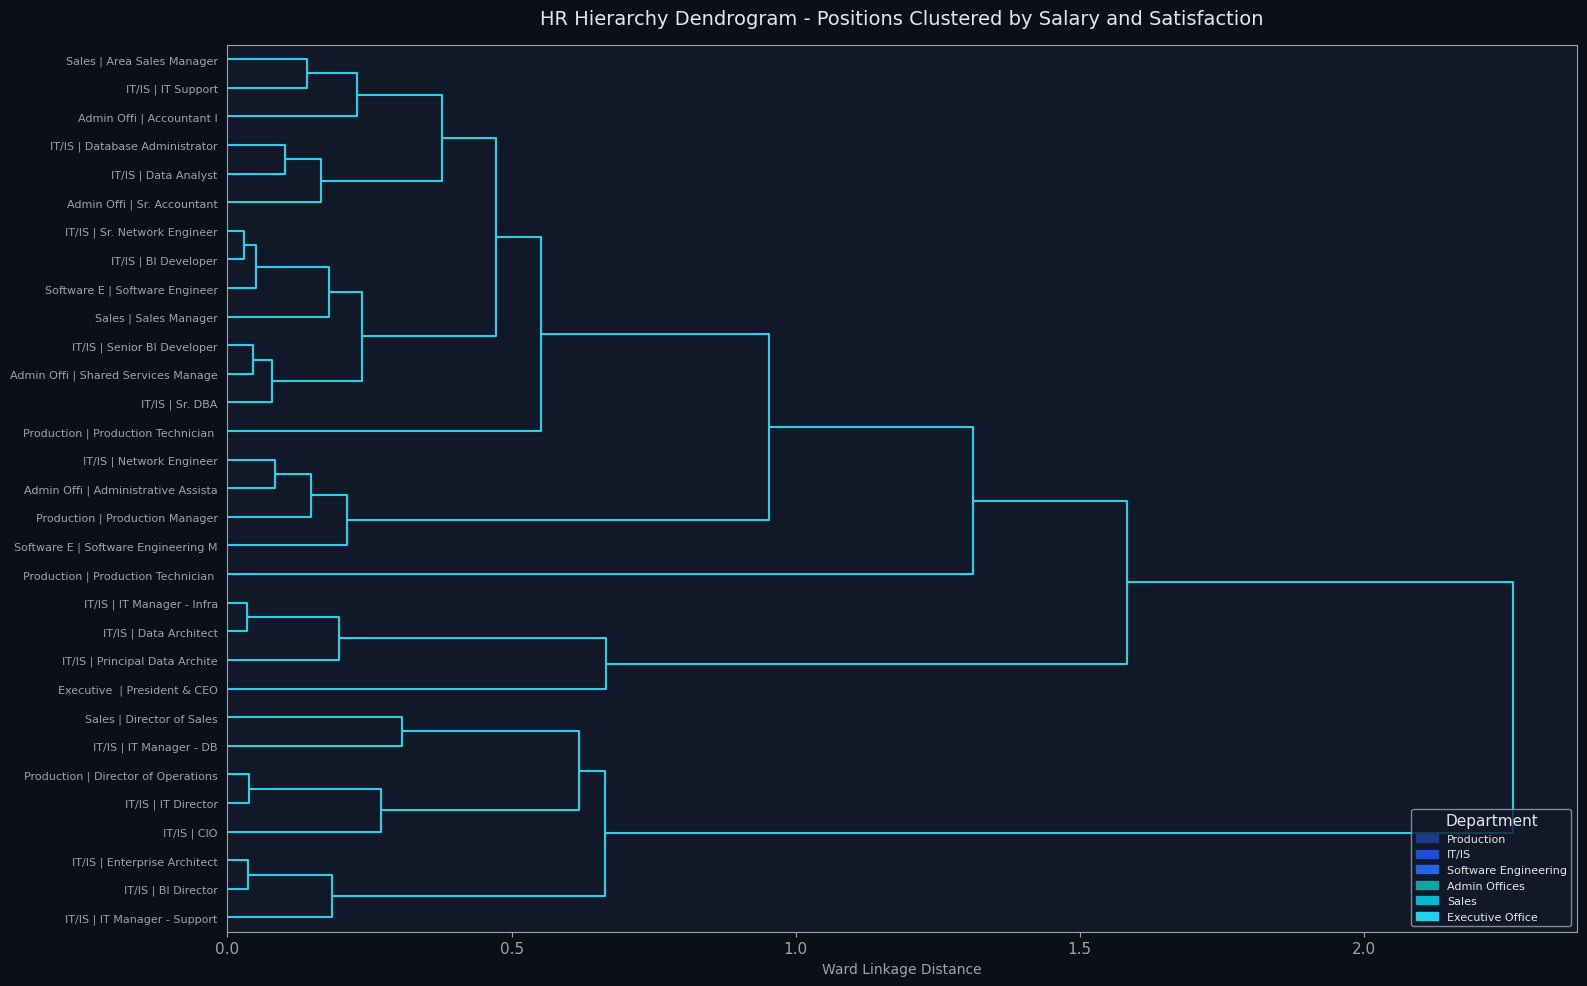

Dendrogram saved -> visualizations/dendrogram.png


In [5]:
dept_pos = (hr.groupby(['Department','Position'])
              .agg(Count=('Employee_Name','count'),
                   AvgSalary=('Salary','mean'),
                   AvgSat=('EmpSatisfaction','mean'))
              .reset_index())
dept_pos['label'] = dept_pos['Department'].str[:10] + ' | ' + dept_pos['Position'].str[:22]
X = dept_pos[['Count','AvgSalary','AvgSat']].fillna(0).values
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-9)
linked = sch.linkage(X, method='ward')

palette = ['#1E3A8A','#1D4ED8','#2563EB','#0EA5A4','#06B6D4','#22D3EE','#67E8F9','#A5F3FC']
dept_colors = {d: palette[i % len(palette)] for i,d in enumerate(hr['Department'].unique())}

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor(BG); ax.set_facecolor(SURFACE)
sch.dendrogram(linked, labels=dept_pos['label'].tolist(), orientation='right',
               leaf_font_size=7.5, color_threshold=0.45*max(linked[:,2]),
               link_color_func=lambda k: ACCENT, ax=ax)
for lbl in ax.get_yticklabels():
    txt = lbl.get_text(); dk = txt.split(' | ')[0].strip()
    matched = [d for d in dept_colors if d[:10].strip() == dk]
    lbl.set_color(dept_colors.get(matched[0], TEXT_PRI) if matched else TEXT_PRI)
    lbl.set_fontsize(8)
ax.set_title('HR Hierarchy Dendrogram - Positions Clustered by Salary and Satisfaction',
             color=TEXT_PRI, fontsize=14, pad=15)
ax.set_xlabel('Ward Linkage Distance', color=TEXT_SEC, fontsize=10)
ax.spines[['top','right','bottom','left']].set_color(TEXT_SEC)
ax.tick_params(colors=TEXT_SEC)
patches = [mpatches.Patch(color=c, label=d) for d,c in dept_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8, title='Department',
          facecolor=SURFACE, edgecolor=TEXT_SEC, labelcolor=TEXT_PRI)
plt.tight_layout()
plt.savefig('visualizations/dendrogram.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Dendrogram saved -> visualizations/dendrogram.png')

---
## Dataset 2: OpenFlights Routes Dataset (Graph Visualization)

**Source:** OpenFlights.org - routes.csv  
**File:** `routes.csv` (67,664 rows) — subset of 600 rows used for performance

This dataset records airline routes between airports worldwide.
It is ideal for **graph visualization** because airports connect to each other
in a non-hierarchical, many-to-many directed network.

### Graph Structure

| Element | Represents |
|---|---|
| **Nodes** | Airports, identified by their 3-letter IATA code (e.g. JFK, LHR, DXB) |
| **Edges** | Directed airline routes — an edge from airport A to airport B means a flight operates from A to B |

**Columns used:** `source airport` (src), `destination airport` (dst), `airline`  
**Subset:** First 600 valid rows → 265 unique airports, 598 directed routes

In [6]:
routes_raw = pd.read_csv('routes.csv', header=0)
routes_raw.columns = ['airline','airline_id','src','src_id','dst','dst_id',
                      'codeshare','stops','equipment']
routes_raw = routes_raw[routes_raw['src'].notna() & routes_raw['dst'].notna()]
routes_raw = routes_raw[routes_raw['src'].str.strip().str.len() == 3]
routes_raw = routes_raw[routes_raw['dst'].str.strip().str.len() == 3]
routes = routes_raw.head(600).copy()

# Build directed graph
G = nx.DiGraph()
for _, row in routes.iterrows():
    G.add_edge(row['src'].strip(), row['dst'].strip(), airline=row['airline'])

deg     = dict(G.degree())
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())
top10   = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:10]
node_list = list(G.nodes())

print('Nodes (airports):', G.number_of_nodes())
print('Edges (routes):  ', G.number_of_edges())
print('Top 10 airports by degree:')
for airport, d in top10:
    print(f'  {airport}: degree={d}, in={in_deg[airport]}, out={out_deg[airport]}')

Nodes (airports): 265
Edges (routes):   598
Top 10 airports by degree:
  MNL: degree=38, in=19, out=19
  SIN: degree=32, in=16, out=16
  DME: degree=26, in=13, out=13
  ARN: degree=26, in=13, out=13
  CMN: degree=22, in=11, out=11
  ZRH: degree=20, in=10, out=10
  FLL: degree=20, in=10, out=10
  IKT: degree=16, in=8, out=8
  OUA: degree=16, in=8, out=8
  DKR: degree=16, in=8, out=8


---
## Graph Visualization 1 - Spring (Force-Directed) Layout

**Algorithm:** Fruchterman-Reingold spring layout (k=1.8, 80 iterations)  
**Why:** Force-directed layouts place highly connected nodes (hubs) at the centre naturally,
revealing the network's core-periphery structure without manual arrangement.  

**Encoding:**
- Node **size** = total degree (more connections = larger)
- Node **colour** = in-degree (darker blue = fewer incoming routes, cyan = hub)
- **Arrows** = direction of the route
- Top 12 hub airports are labelled

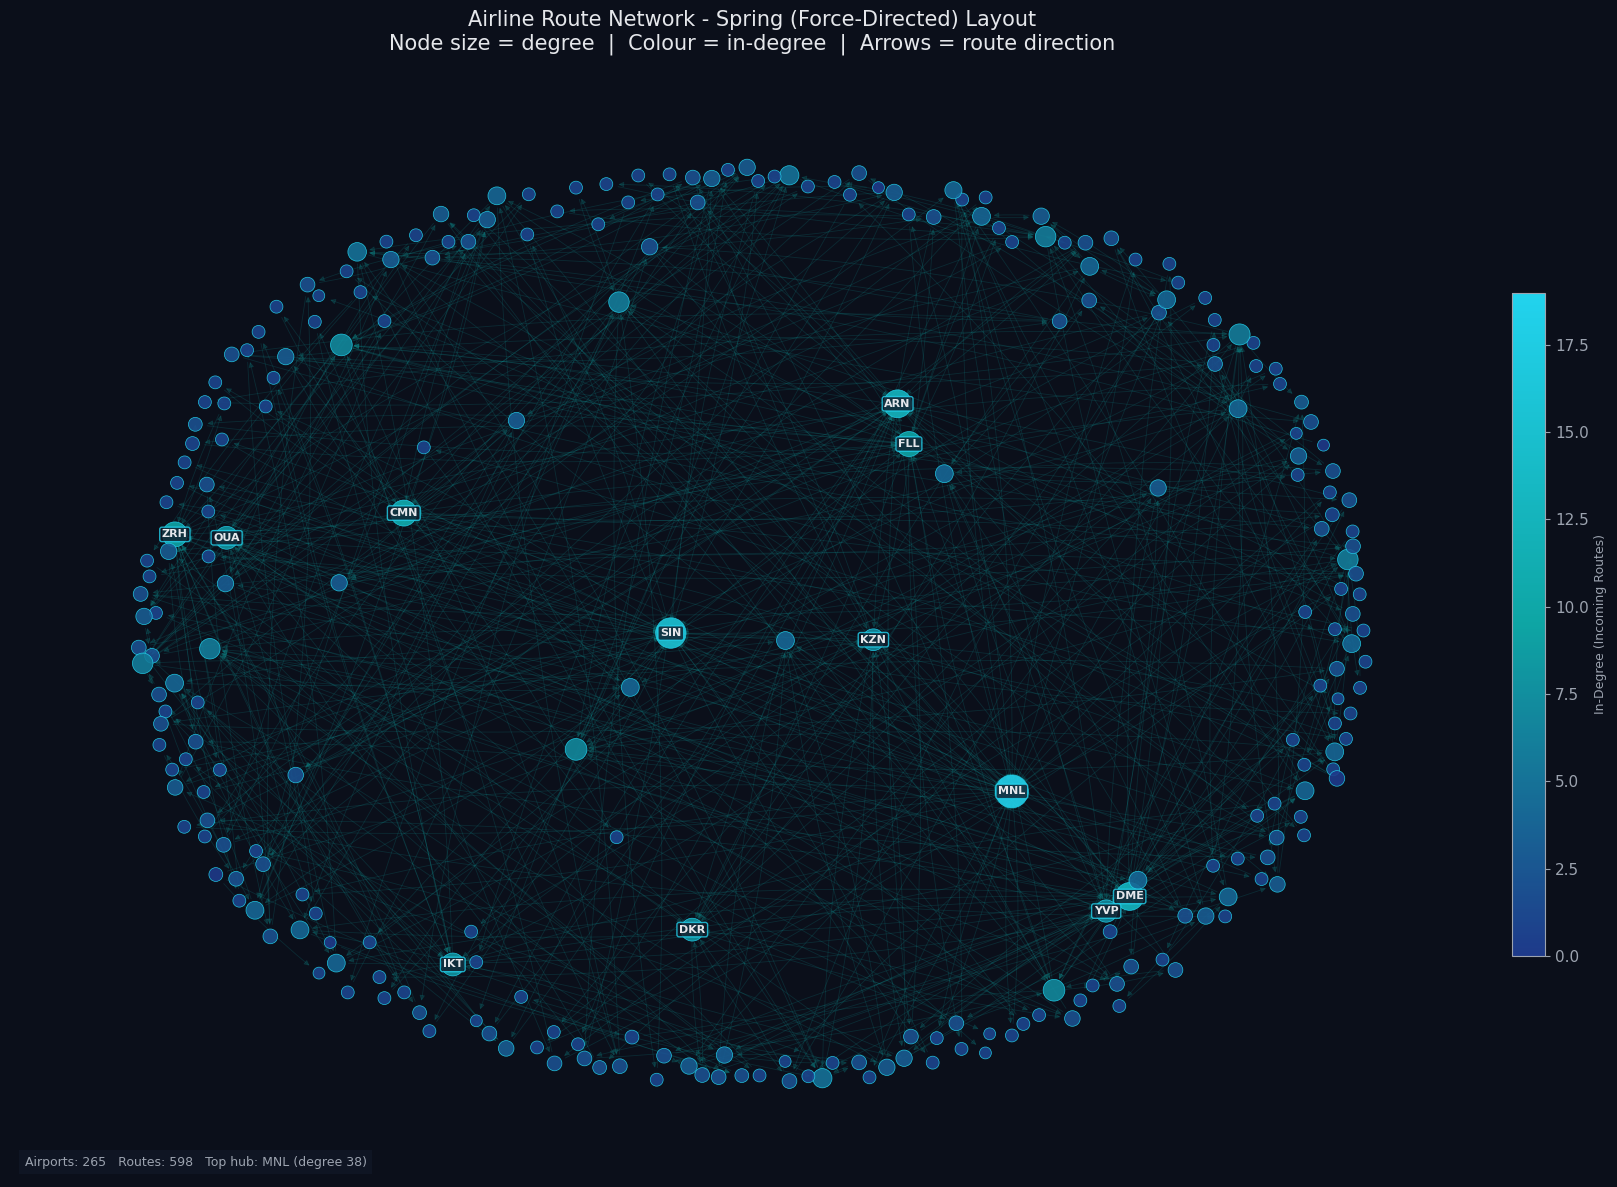

Spring layout saved -> visualizations/graph_spring.png


In [7]:
np.random.seed(42)
cmap = mcolors.LinearSegmentedColormap.from_list('blue_teal', [PRIMARY, SECONDARY, ACCENT])
pos_spring = nx.spring_layout(G, k=1.8, iterations=80, seed=42)

degrees  = np.array([deg[n] for n in node_list])
in_degs  = np.array([in_deg[n] for n in node_list])
node_sizes  = 60 + (degrees / degrees.max()) * 500
norm        = mcolors.Normalize(vmin=in_degs.min(), vmax=in_degs.max())
node_colors = [cmap(norm(v)) for v in in_degs]

fig, ax = plt.subplots(figsize=(18, 12))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
nx.draw_networkx_edges(G, pos_spring, ax=ax, edge_color=SECONDARY,
    alpha=0.18, width=0.6, arrows=True, arrowstyle='-|>', arrowsize=8,
    connectionstyle='arc3,rad=0.05')
nx.draw_networkx_nodes(G, pos_spring, ax=ax, nodelist=node_list,
    node_size=node_sizes, node_color=node_colors,
    alpha=0.9, linewidths=0.5, edgecolors=ACCENT)
top12 = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:12]
top12_pos = {n: pos_spring[n] for n, _ in top12}
nx.draw_networkx_labels(G, top12_pos, ax=ax, labels={n: n for n in top12_pos},
    font_size=8, font_color=TEXT_PRI, font_weight='bold',
    bbox=dict(boxstyle='round,pad=0.2', facecolor=SURFACE, edgecolor=ACCENT, alpha=0.8))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label('In-Degree (Incoming Routes)', color=TEXT_SEC, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=TEXT_SEC)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_SEC)
cbar.outline.set_edgecolor(TEXT_SEC)
ax.set_title(
    'Airline Route Network - Spring (Force-Directed) Layout\n'
    'Node size = degree  |  Colour = in-degree  |  Arrows = route direction',
    color=TEXT_PRI, fontsize=15, pad=16)
ax.axis('off')
ax.text(0.01, 0.01,
    'Airports: {}   Routes: {}   Top hub: {} (degree {})'.format(
        G.number_of_nodes(), G.number_of_edges(), top10[0][0], top10[0][1]),
    transform=ax.transAxes, color=TEXT_SEC, fontsize=9,
    bbox=dict(facecolor=SURFACE, edgecolor='none', alpha=0.7))
plt.tight_layout()
plt.savefig('visualizations/graph_spring.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Spring layout saved -> visualizations/graph_spring.png')

---
## Graph Visualization 2 - Circular (Shell) Layout

**Algorithm:** Shell layout — 3 concentric rings sorted by degree tier  
**Why:** Explicitly shows the tier structure of the network:
dominant hubs (inner), mid-tier connectors (middle), peripheral airports (outer).  

**Ring assignment:**
- Inner ring (top 20% by degree) = hub airports
- Middle ring (next 30%) = mid-tier connectors
- Outer ring (remaining 50%) = peripheral airports

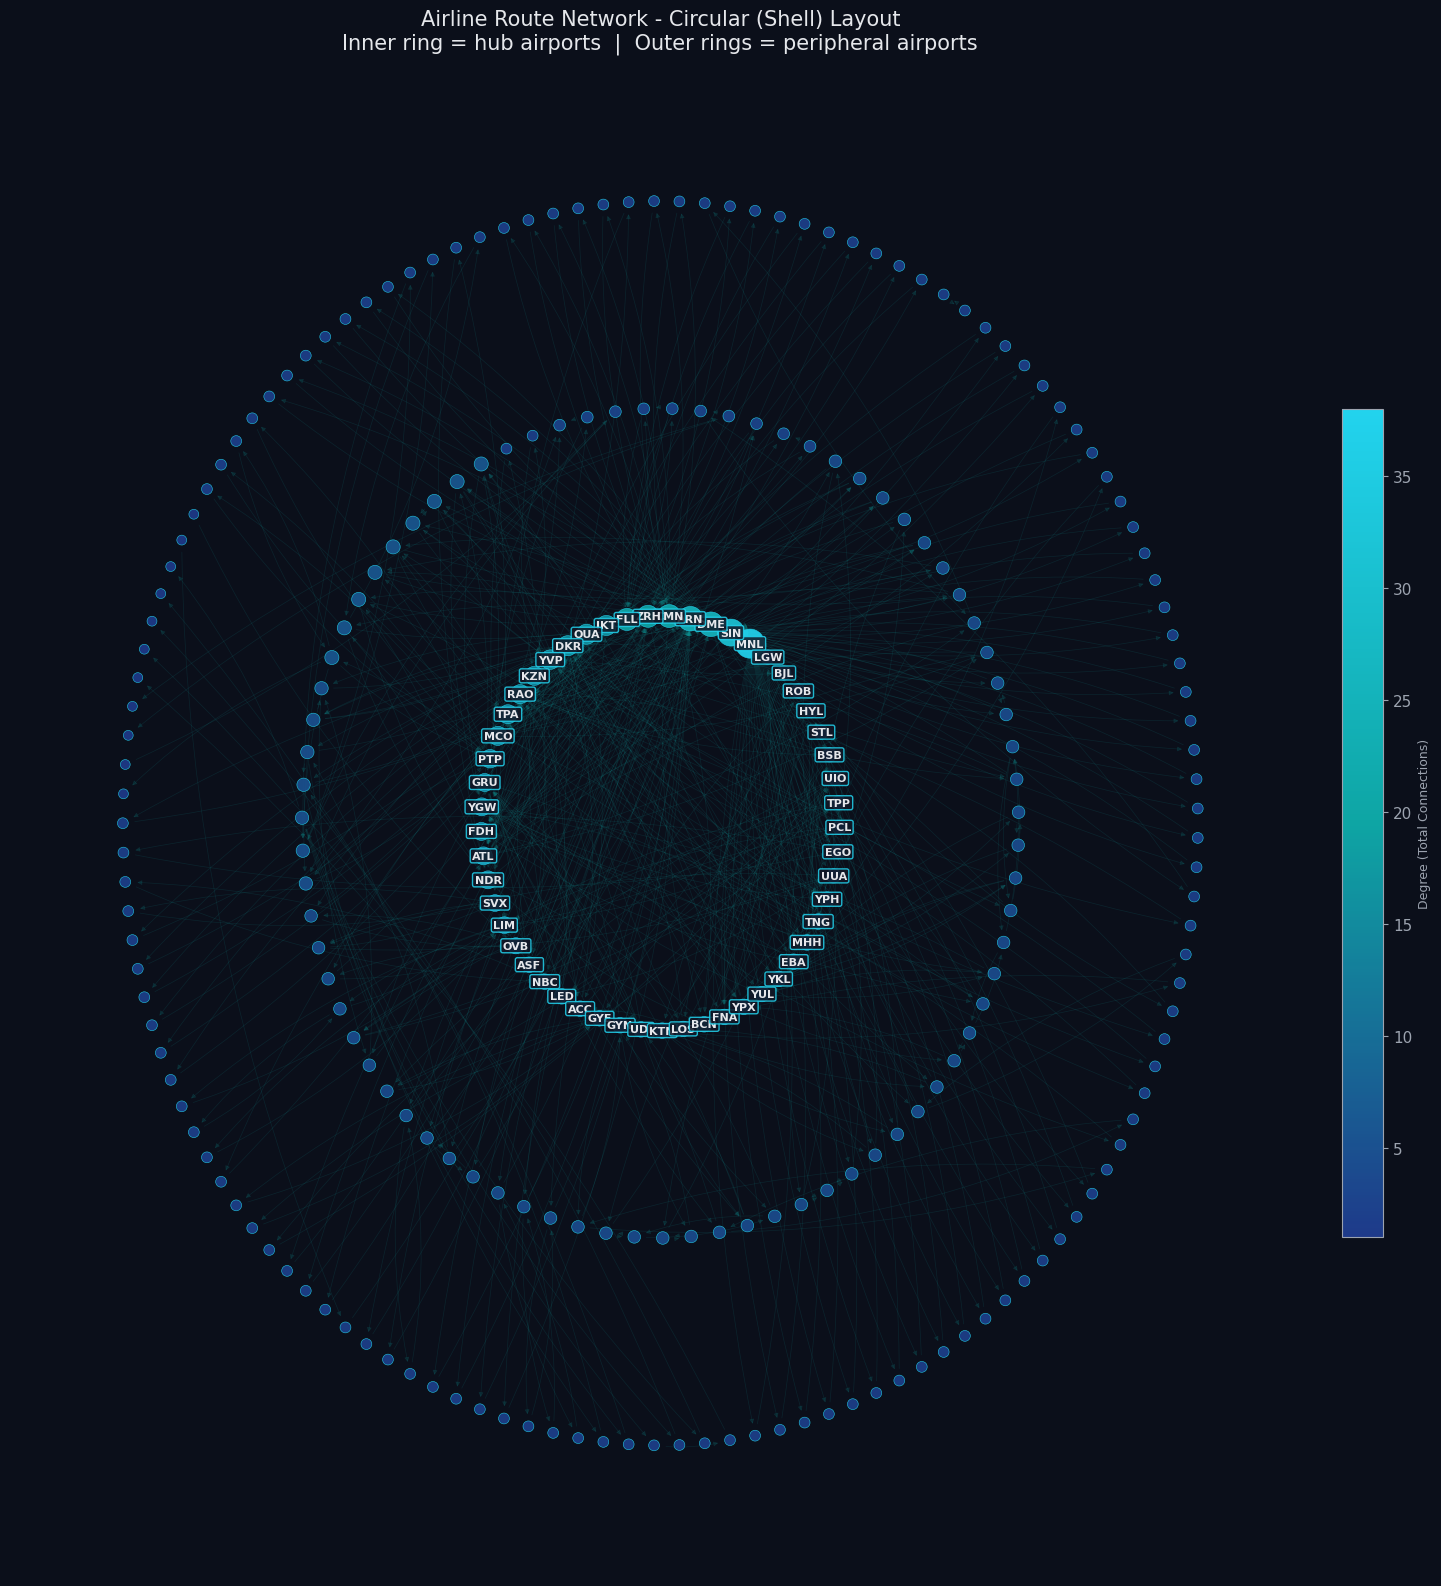

Circular layout saved -> visualizations/graph_circular.png


In [8]:
sorted_nodes = sorted(deg.items(), key=lambda x: x[1], reverse=True)
n_nodes = len(sorted_nodes)
tier1 = [nd for nd, _ in sorted_nodes[:max(1, n_nodes//5)]]
tier2 = [nd for nd, _ in sorted_nodes[n_nodes//5: n_nodes//2]]
tier3 = [nd for nd, _ in sorted_nodes[n_nodes//2:]]
pos_circ = nx.shell_layout(G, nlist=[tier1, tier2, tier3])

circ_deg    = np.array([deg[nd] for nd in node_list])
circ_norm   = mcolors.Normalize(vmin=circ_deg.min(), vmax=circ_deg.max())
circ_colors = [cmap(circ_norm(v)) for v in circ_deg]
circ_sizes  = 40 + (circ_deg / circ_deg.max()) * 400

fig, ax = plt.subplots(figsize=(16, 16))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
nx.draw_networkx_edges(G, pos_circ, ax=ax, edge_color=SECONDARY,
    alpha=0.14, width=0.5, arrows=True, arrowstyle='-|>', arrowsize=7,
    connectionstyle='arc3,rad=0.1')
nx.draw_networkx_nodes(G, pos_circ, ax=ax, nodelist=node_list,
    node_size=circ_sizes, node_color=circ_colors,
    alpha=0.92, linewidths=0.4, edgecolors=ACCENT)
nx.draw_networkx_labels(G, pos_circ, ax=ax, labels={nd: nd for nd in tier1},
    font_size=8, font_color=TEXT_PRI, font_weight='bold',
    bbox=dict(boxstyle='round,pad=0.18', facecolor=SURFACE, edgecolor=ACCENT, alpha=0.85))
ax.set_title(
    'Airline Route Network - Circular (Shell) Layout\n'
    'Inner ring = hub airports  |  Outer rings = peripheral airports',
    color=TEXT_PRI, fontsize=15, pad=16)
ax.axis('off')
sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=circ_norm); sm2.set_array([])
cbar2 = plt.colorbar(sm2, ax=ax, shrink=0.55, pad=0.02)
cbar2.set_label('Degree (Total Connections)', color=TEXT_SEC, fontsize=9)
cbar2.ax.yaxis.set_tick_params(color=TEXT_SEC)
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color=TEXT_SEC)
cbar2.outline.set_edgecolor(TEXT_SEC)
plt.tight_layout()
plt.savefig('visualizations/graph_circular.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Circular layout saved -> visualizations/graph_circular.png')

---
## Summary

### Dataset 1 - HR Dataset (Tree)
- **Nodes:** Company root, 6 departments, 31 job positions
- **Edges:** Containment relationships (Company contains Departments; Departments contain Positions)
- **Layout 1 (Treemap):** Area = headcount; colour = avg salary. Production is the largest department.
- **Layout 2 (Dendrogram):** Ward linkage clustering reveals IT/IS positions are structurally similar (tight cluster), while Production positions are diverse.

### Dataset 2 - Routes Dataset (Graph)
- **Nodes:** 265 airports identified by IATA code
- **Edges:** 598 directed airline routes (A -> B means a flight operates from A to B)
- **Layout 1 (Spring):** Force-directed — hub airports emerge at the centre organically.
- **Layout 2 (Circular):** Shell rings explicitly show hub/mid/peripheral tier structure.

**GitHub Pages:** https://mariumgk.github.io/DataVis-Assignment4/